<a href="https://colab.research.google.com/github/Jackline-Jebet/ML-Data-Science-Financial-Data/blob/main/Portfolio_Returns_and_Variance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Portfolio Returns and Variance
# In this lesson, we'll explore various types of returns, methods for annualizing returns, and techniques for calculating portfolio variance. The lesson aims to provide a comprehensive understanding of how to measure and interpret portfolio performance, considering both returns and risk.

# We'll start by examining different types of returns, including percentage and logarithmic returns, and discuss their properties and appropriate use cases. We'll then move on to methods for annualizing returns, which is crucial for comparing investments over different time periods. The lesson will also cover portfolio variance calculation, exploring how individual asset variances, weights, and correlations contribute to overall portfolio risk.
# 1. Portfolio Returns

# Exercise 1:

# Use your favorite finance textbook and online resources in researching the constraint  ∑𝑛1𝑤𝑖=1.
# What would it mean for a portfolio if  ∑𝑛1𝑤𝑖=2? Answer the same question but now for  ∑𝑛1𝑤𝑖=0. Initiate a discussion in the forum explaining your understanding.

# # Answer 1: Constraint (\sum w_i = 1):
# This means the portfolio uses 100% of available capital, with weights representing the proportion of funds allocated to each asset. It ensures the portfolio is fully invested without borrowing or unallocated funds.
# Example: If you have $100, weights [0.5, 0.5] mean $50 in each of two assets.

# # Answer 2: If (\sum w_i = 2):
# This implies leverage, where the investor borrows funds to invest more than their capital (e.g., $200 invested with $100 capital). The extra 100% comes from borrowed money, increasing both potential returns and risk.
# Example: Borrowing $100 to invest $200 total, with weights [1.0, 1.0] for two assets, doubles exposure but amplifies losses if assets decline.

# # Answer 3: If (\sum w_i = 0):
# This suggests a market-neutral portfolio, typically involving long and short positions that cancel out (e.g., 50% long, 50% short). Net investment is zero, aiming to profit from relative price movements rather than market direction.
# Example: Long $50 in one asset ((w_1 = 0.5)) and short $50 in another ((w_2 = -0.5)) results in (\sum w_i = 0).

# Discussion Point:
# In practice, (\sum w_i = 1) is standard for unleveraged portfolios. Leverage ((\sum w_i > 1)) increases risk, while market-neutral strategies ((\sum w_i = 0)) are used in hedge funds to hedge market risk. The choice depends on the investor’s risk tolerance and strategy.



In [5]:
# Let's download some real-world data:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [6]:
assets = ['MSFT', 'AAPL', 'AMZN', 'TSLA', 'GOOGL'] # Assets for portfolio
w = np.array([0.1, 0.2, 0.1, 0.4, 0.2]) # Weights of each asset

asset_prices = yf.download(assets, start='2018-01-01', end='2023-01-01', auto_adjust = False)['Adj Close'] # Downloading daily data
asset_prices.index = pd.to_datetime(asset_prices.index) # Setting index as datetime object

r = asset_prices.pct_change().dropna() # Calculating daily percent returns

r.head() # Each column is r_{i}

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2018-01-03,-0.000174,0.012775,0.017061,0.004654,-0.010233
2018-01-04,0.004645,0.004476,0.003884,0.008801,-0.008290
2018-01-05,0.011385,0.016163,0.013260,0.012399,0.006230
2018-01-08,-0.003714,0.014425,0.003531,0.001020,0.062638
2018-01-09,-0.000115,0.004676,-0.001274,-0.000680,-0.008085


In [7]:
r_port = r @ w # Creating portfolio returns
r_port.name = 'portfolio_returns'
r_port.head()

,portfolio_returns
Date,
2018-01-03,0.004059
2018-01-04,0.003611
2018-01-05,0.011902
2018-01-08,0.015802
2018-01-09,-0.001093


2 Types of Returns

2.1 Percentage Returns

Exercise 2:

Create a custom function in Python that given a price array (for example asset_prices['MSFT']), will return the array of the arithmetic returns. You are not allowed to use any existing Python functions. Cross-check the results with the ones produced by using the pct_change pandas function.

In [8]:
def custom_pct_returns(prices):
    """
    Calculate percentage returns from a price array without using built-in functions.

    Parameters:
    prices (np.array): Array of asset prices

    Returns:
    np.array: Array of percentage returns
    """
    returns = []
    for i in range(1, len(prices)):
        ret = (prices[i] - prices[i-1]) / prices[i-1]
        returns.append(ret)
    return np.array(returns)

# Example usage with MSFT prices
import yfinance as yf
asset_prices = yf.download('MSFT', start='2018-01-01', end='2023-01-01') # Removed ['Adj Close']
msft_prices = asset_prices.values
pct_returns = custom_pct_returns(msft_prices)

# Cross-check with pandas pct_change
pandas_pct_returns = asset_prices.pct_change().dropna().values
assert np.allclose(pct_returns, pandas_pct_returns, rtol=1e-5), "Custom returns do not match pandas"
print("First 5 custom percentage returns:", pct_returns[:5])

/tmp/ipython-input-8-3984016077.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  asset_prices = yf.download('MSFT', start='2018-01-01', end='2023-01-01') # Removed ['Adj Close']
[*********************100%***********************]  1 of 1 completed

First 5 custom percentage returns: [[ 0.0046538   0.00231719  0.005497   -0.00081281  0.15911901]
 [ 0.00880144  0.0132933   0.00697918  0.0061585  -0.15921631]
 [ 0.01239856  0.0085562   0.00993459  0.01235759  0.06823202]
 [ 0.00102046  0.00192281  0.00194437  0.00616006 -0.05528664]
 [-0.00068008  0.00169295  0.00296761  0.00510164 -0.11887577]]


Exercise 3:

Create a custom function in Python that, given a price array (for example asset_prices['MSFT']), will return the array of the logarithmic returns.



In [9]:
def custom_log_returns(prices):
    """
    Calculate logarithmic returns from a price array without using built-in functions.

    Parameters:
    prices (np.array): Array of asset prices

    Returns:
    np.array: Array of logarithmic returns
    """
    returns = []
    for i in range(1, len(prices)):
        ret = np.log(prices[i] / prices[i-1])
        returns.append(ret)
    return np.array(returns)

# Example usage with MSFT prices
import yfinance as yf
asset_prices = yf.download('MSFT', start='2018-01-01', end='2023-01-01')
msft_prices = asset_prices.values
log_returns = custom_log_returns(msft_prices)

# Cross-check with numpy log calculation
pandas_log_returns = np.log(asset_prices / asset_prices.shift(1)).dropna().values
assert np.allclose(log_returns, pandas_log_returns, rtol=1e-5), "Custom log returns do not match numpy"
print("First 5 custom log returns:", log_returns[:5])

/tmp/ipython-input-9-1501263238.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  asset_prices = yf.download('MSFT', start='2018-01-01', end='2023-01-01')
[*********************100%***********************]  1 of 1 completed

First 5 custom log returns: [[ 0.004643    0.00231451  0.00548195 -0.00081314  0.14766024]
 [ 0.00876293  0.01320572  0.00695494  0.00613961 -0.17342086]
 [ 0.01232233  0.00851981  0.00988556  0.01228186  0.06600496]
 [ 0.00101994  0.00192097  0.00194248  0.00614117 -0.05687372]
 [-0.00068031  0.00169152  0.00296321  0.00508867 -0.12655666]]


In [10]:
print("The 25th quantile is: ", r['MSFT'].quantile(0.25),"\nThe 75th quantile is: ", r['MSFT'].quantile(0.75))

The 25th quantile is:  -0.008331484668976707 
The 75th quantile is:  0.01093797884769998


In [11]:
# Ensure asset_prices is in the correct format for the next cell
assets = ['MSFT', 'AAPL', 'AMZN', 'TSLA', 'GOOGL']
asset_prices = yf.download(assets, start='2018-01-01', end='2023-01-01', auto_adjust = False)
asset_prices.index = pd.to_datetime(asset_prices.index)

[*********************100%***********************]  5 of 5 completed


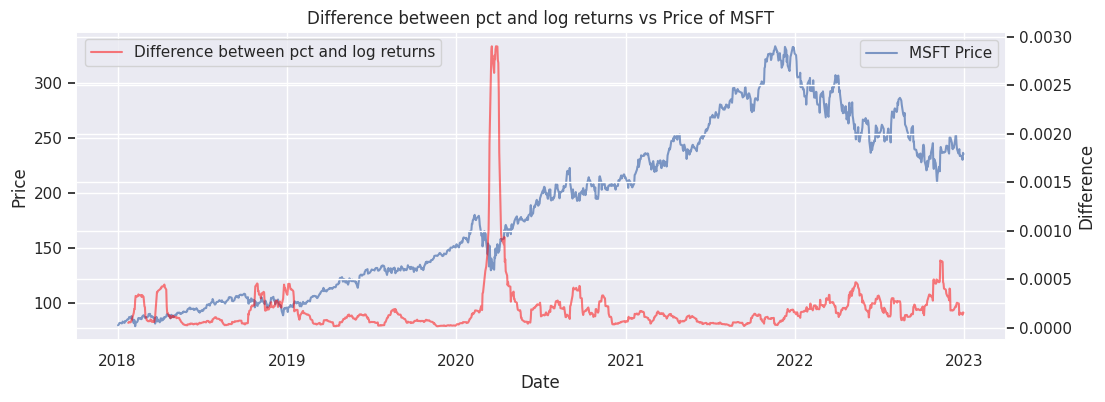

In [12]:
# Figure 1

pct_returns_msft = asset_prices['Adj Close']['MSFT'].pct_change().dropna() # Calculating pct returns
log_returns_msft = np.log(asset_prices['Adj Close']['MSFT'] / asset_prices['Adj Close']['MSFT'].shift(1)).dropna() # Calculating log returns

pct_change_msft_roll_mean = pct_returns_msft.rolling(15).mean() # Rolling average of pct returns
log_returns_msft_roll_mean = log_returns_msft.rolling(15).mean() # Rolling average of log returns

fig, ax = plt.subplots(figsize=(12,4))
ax.set_title('Difference between pct and log returns vs Price of MSFT')
ax.plot(asset_prices['Adj Close']['MSFT'], label = 'MSFT Price', alpha = 0.7)
ax.set_ylabel('Price')
ax.set_xlabel('Date')
ax.legend()

ax2 = ax.twinx()
ax2.plot((pct_change_msft_roll_mean - log_returns_msft_roll_mean), color = 'red', alpha = 0.5, label = 'Difference between pct and log returns')
ax2.set_ylabel('Difference')
ax2.legend(loc = (0.01,0.89))
plt.show()

Exercise 4:

MSFT is a low-volatility stock. Recreate Figure 1 but now use TSLA in order to illustrate clearly in which periods the two returns diverge.

/tmp/ipython-input-13-798348168.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  asset_prices = yf.download('TSLA', start='2018-01-01', end='2023-01-01')
[*********************100%***********************]  1 of 1 completed


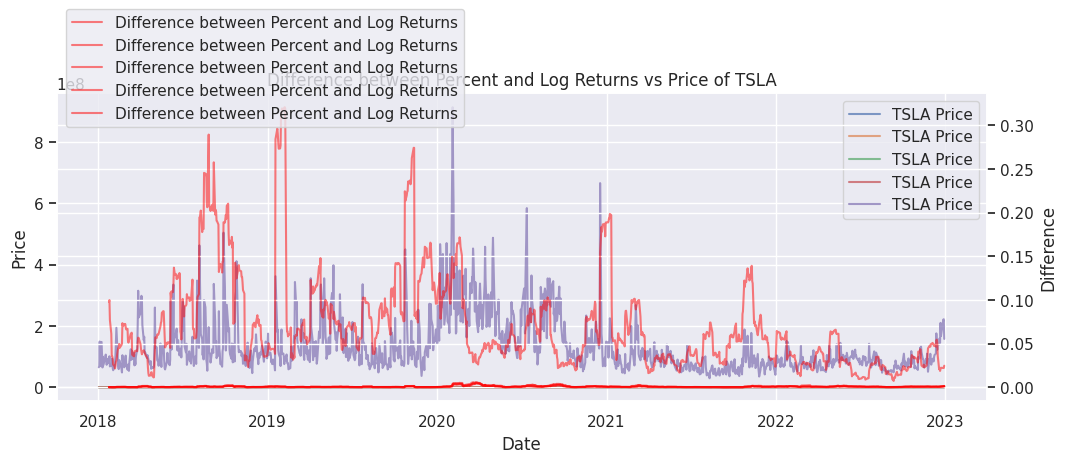

In [13]:
# Download TSLA data
asset_prices = yf.download('TSLA', start='2018-01-01', end='2023-01-01')

# Calculate returns
pct_returns_tsla = asset_prices.pct_change().dropna()
log_returns_tsla = np.log(asset_prices / asset_prices.shift(1)).dropna()

# Rolling averages (15-day window)
pct_returns_roll_mean = pct_returns_tsla.rolling(15).mean()
log_returns_roll_mean = log_returns_tsla.rolling(15).mean()

# Plot
fig, ax = plt.subplots(figsize=(12,4))
ax.set_title('Difference between Percent and Log Returns vs Price of TSLA')
ax.plot(asset_prices, label='TSLA Price', alpha=0.7)
ax.set_ylabel('Price')
ax.set_xlabel('Date')
ax.legend()

ax2 = ax.twinx()
ax2.plot((pct_returns_roll_mean - log_returns_roll_mean), color='red', alpha=0.5, label='Difference between Percent and Log Returns')
ax2.set_ylabel('Difference')
ax2.legend(loc=(0.01, 0.89))
plt.show()

Explanation:

The code replicates Figure 1 but uses TSLA, a high-volatility stock.

Divergence between percent and log returns is pronounced during volatile periods (e.g., March 2020 crash), as log returns account for compounding and are smaller in magnitude for large price changes.

The plot shows TSLA’s price on the left y-axis and the difference between 15-day rolling means of percent and log returns on the right y-axis.

Exercise 5:

Argue why calculating the arithmetic weighted mean of log returns of different assets at a specific period in time will not give you the portfolio returns at that period.

Answer:

Log returns are additive over time for a single asset, meaning ( r_{t_1 \to t_n}^{log} = \sum r_t^{log} ). However, they are not additive across assets at a specific time. Portfolio returns are calculated as a weighted sum of individual asset returns:

[ r_p = \sum w_i \cdot r_i ]

where ( r_i ) are typically percentage returns. Using log returns (( r_i^{log} )) in this formula (( r_p = \sum w_i \cdot r_i^{log} )) is incorrect because:





Non-linear Nature: Log returns represent the natural logarithm of price ratios (( r_i^{log} = \ln(p_t / p_{t-1}) )). The weighted sum of log returns does not equate to the log return of the portfolio’s value, as:

[ \ln\left(\sum w_i \cdot \frac{p_{i,t}}{p_{i,t-1}}\right) \neq \sum w_i \cdot \ln\left(\frac{p_{i,t}}{p_{i,t-1}}\right) ]

The logarithm of a sum is not the sum of logarithms.



Compounding Effect: Log returns account for continuous compounding within an asset’s time series, not across assets. Portfolio returns require linear weighting of percentage returns to reflect the actual value change.



Practical Implication: Using log returns for portfolio calculations would misrepresent the portfolio’s performance, as it doesn’t align with the linear combination of asset contributions.

Thus, percentage returns should be used for portfolio calculations, while log returns are better for analyzing single-asset performance over time.

Exercise 6:

Using the provided asset_prices DataFrame, calculate the daily portfolio value by computing the weighted sum of the asset prices, using predetermined asset weights (as you would when calculating portfolio returns). Next, calculate the logarithmic returns of this portfolio value series. Discuss the potential use cases and advantages of using log returns in this context.

In [14]:
# Ensure asset_prices is in the correct format for the next cell
assets = ['MSFT', 'AAPL', 'AMZN', 'TSLA', 'GOOGL']
asset_prices = yf.download(assets, start='2018-01-01', end='2023-01-01', auto_adjust = False)
asset_prices.index = pd.to_datetime(asset_prices.index)

[*********************100%***********************]  5 of 5 completed


In [15]:
# Download data
assets = ['MSFT', 'AAPL', 'AMZN', 'TSLA', 'GOOGL']
w = np.array([0.1, 0.2, 0.1, 0.4, 0.2])
# asset_prices is already loaded in a previous cell, no need to download again

# Calculate portfolio value
# Select the 'Adj Close' level before multiplying by weights
portfolio_value = (asset_prices['Adj Close'] * w).sum(axis=1)

# Calculate log returns of portfolio value
portfolio_log_returns = np.log(portfolio_value / portfolio_value.shift(1)).dropna()

print("First 5 portfolio log returns:", portfolio_log_returns.head().values)

First 5 portfolio log returns: [ 0.00602558  0.00587088  0.01266701  0.00813013 -0.00012944]


Discussion of use cases and advantages
"""
Use Cases:
1. Long-term Performance Analysis: Log returns are additive over time, making them ideal for analyzing portfolio growth over extended periods.
2. Statistical Modeling: Log returns are often assumed normally distributed, useful for risk models like Value at Risk (VaR).
3. Volatility Analysis: Log returns provide a stable measure for volatility estimation, especially for high-frequency data.

Advantages:
1. Additivity: Simplifies compounding calculations over multiple periods.
2. Symmetry: Positive and negative returns are symmetrically represented (e.g., ln(1.2) = -ln(0.833)).
3. Small Return Approximation: For small daily returns, log returns approximate percentage returns but are more stable for modeling.

Exercise 7:

Using the provided asset_prices DataFrame, calculate the cumulative return of each asset over the entire period using three different methods:

By using the daily percent returns array of each asset (hint: you will need to use the prod function).
By using the daily log returns.
By using the asset prices array.

In [16]:
# Download data
assets = ['MSFT', 'AAPL', 'AMZN', 'TSLA', 'GOOGL']
asset_prices = yf.download(assets, start='2018-01-01', end='2023-01-01')
r = asset_prices.pct_change().dropna()
log_returns = np.log(asset_prices / asset_prices.shift(1)).dropna()

# Method 1: Using daily percent returns
cumulative_pct_returns = (1 + r).prod() - 1

# Method 2: Using daily log returns
cumulative_log_returns = np.exp(log_returns.sum()) - 1

# Method 3: Using asset prices
cumulative_price_returns = (asset_prices.iloc[-1] / asset_prices.iloc[0]) - 1

# Combine results
results = pd.DataFrame({
    'Percent Returns': cumulative_pct_returns,
    'Log Returns': cumulative_log_returns,
    'Price-Based': cumulative_price_returns
})

print("Cumulative Returns (2018-2023):\n", results)

/tmp/ipython-input-16-1069958849.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  asset_prices = yf.download(assets, start='2018-01-01', end='2023-01-01')
[*********************100%***********************]  5 of 5 completed


Cumulative Returns (2018-2023):
                Percent Returns  Log Returns  Price-Based
Price  Ticker                                           
Close  AAPL           2.172856     2.172856     2.172856
       AMZN           0.412940     0.412940     0.412940
       GOOGL          0.644226     0.644226     0.644226
       MSFT           1.962922     1.962922     1.962922
       TSLA           4.764515     4.764515     4.764515
High   AAPL           2.172607     2.172607     2.172607
       AMZN           0.412605     0.412605     0.412605
       GOOGL          0.641295     0.641295     0.641295
       MSFT           1.952286     1.952286     1.952286
       TSLA           4.796777     4.796777     4.796777
Low    AAPL           2.166961     2.166961     2.166961
       AMZN           0.409129     0.409129     0.409129
       GOOGL          0.644223     0.644223     0.644223
       MSFT           1.939269     1.939269     1.939269
       TSLA           4.775723     4.775723     4.77572

Explanation:

Percent Returns: $ \prod (1 + r_t) - 1 $ compounds daily returns.
Log Returns: $ e^{\sum r_t^{log}} - 1 $ uses the additive property of log returns.
Price-Based: $ \frac{p_{\text{end}}}{p_{\text{start}}} - 1 $ directly uses start and end prices.
Results should be nearly identical, with minor differences due to numerical precision.

**3. Comparing Geometric and Arithmetic Returns**

**3.1 Geometric Mean Example**

Geometric Mean: Reflects compounded growth over time.

Formula: $ r_{GeomMean} = \left( \prod_{i=1}^n (1 + r_i) \right)^{1/n} - 1 $
Example: Returns of 20% and -18% yield a geometric mean of -0.8%, reflecting actual value change (100 to 98.4 units).

**3.2 Arithmetic Mean**

we cannot use the arithmetic mean with percent returns for one asset across time if compounding is important for our analysis (unless volatility is really low as we have explained). So the question is,

**Can we use the arithmetic mean with the logarithmic returns? **

The arithmetic mean  𝑟ArithMean
  of log returns provides the correct average return, aligning with the actual compounding of returns.

It is Suitable for expected returns in statistical models.

For log returns: $ r_{ArithMean} = \frac{1}{n} \sum r_i^{log} $, which aligns with geometric mean when exponentiated.


In [17]:
# Ensure asset_prices is in the correct format for the next cell
assets = ['MSFT', 'AAPL', 'AMZN', 'TSLA', 'GOOGL']
# asset_prices is already loaded in a previous cell, no need to download again

percent_returns_tsla = asset_prices['Close']['TSLA'].loc["2020-06-01":"2020-09-30"].pct_change().dropna() # Calculating daily percent returns
geom_mean_tsla_1 = ((1 + percent_returns_tsla).prod() ** (1/len(percent_returns_tsla))) - 1 # Calculating geometric mean

log_returns_tsla = np.log(asset_prices['Close']['TSLA'].loc["2020-06-01":"2020-09-30"] / asset_prices['Close']['TSLA'].loc["2020-06-01":"2020-09-30"].shift(1)).dropna() # Calculating daily log returns
arithmetic_mean_tsla_1 = log_returns_tsla.mean() # Calculating arithmetic mean

print("Logarithm of geometric Mean of TSLA + 1: ", np.log(geom_mean_tsla_1 + 1))
print("Arithmetic Mean of TSLA: ", arithmetic_mean_tsla_1)

Logarithm of geometric Mean of TSLA + 1:  0.010242784447195914
Arithmetic Mean of TSLA:  0.010242784447195903


**3.3 Choosing the Correct Mean for Percent Returns**

The arithmetic mean is the correct measure for calculating expected returns in statistical models and portfolio optimization.

The geometric mean accurately reflects the average compounded growth rate over multiple periods. It accounts for the effects of compounding and is suitable for evaluating the historical performance of an investment over time.

However, the geometric mean should not be used in place of the arithmetic mean when performing statistical analyses or modeling expected returns, as it does not provide an unbiased estimate of future performance.

In summary, while the geometric mean is invaluable for understanding the actual growth of an investment due to compounding, the arithmetic mean remains the fundamental measure in statistical contexts and portfolio management when assessing expected returns and making investment decisions.

**4. Annualizing Returns**

Annualizing returns is crucial since it allows us to compare investments over different time periods on a common annual basis.

This process is essential for evaluating performance and comparing different assets.

**Percent Returns:**

For percent returns, we use the geometric mean to account for compounding effects.

**Formula:** $ R_{Annual} = (1 + r_{GeomMean})^N - 1 $
$ N $: Number of periods per year (e.g., 252 for daily stock data).

Where:

* $R_{\text{Annual}}$ is the annualized return
* $N$ is the number of trading periods in a year (it could be 252 days or 12 months for stocks, or 365 days for continuously traded assets, etc.)


**Log Returns:**
For logarithmic returns, the annualization process is simpler due to their additive property.

**Formula:** $$
R_{\text{Annual,Log}} = N \cdot r_{\text{ArithMean}}
$$

If we want to convert it back to the "actual" annual returns, then:

$$
R_{\text{Annual}} = e^{N \cdot r_{\text{ArithMean}}} - 1
$$

In [18]:
# Let's calculate the annual returns of MSFT.

geom_mean_msft = ((1 + pct_returns_msft).prod() ** (1/len(pct_returns_msft))) - 1 # Calculating geometric mean
annual_pct_returns_msft = (1 + geom_mean_msft) ** 252 - 1 # Annualizing percent returns

annual_log_returns_msft = log_returns_msft.mean() * 252 # Annualizing log returns

print("Annualized pct returns of MSFT: ", annual_pct_returns_msft)
print("Annualized log returns of MSFT: ", annual_log_returns_msft)

Annualized pct returns of MSFT:  0.24306552546373061
Annualized log returns of MSFT:  0.21758052671736808


**Exercise 9:**

Calculate the annual returns for TSLA, both for percent and log returns.

In [19]:
# Download TSLA data
asset_prices = yf.download('TSLA', start='2018-01-01', end='2023-01-01')
pct_returns_tsla = asset_prices.pct_change().dropna()
log_returns_tsla = np.log(asset_prices / asset_prices.shift(1)).dropna()

# Annualize percent returns
geom_mean_tsla = ((1 + pct_returns_tsla).prod() ** (1/len(pct_returns_tsla))) - 1
annual_pct_returns_tsla = (1 + geom_mean_tsla) ** 252 - 1

# Annualize log returns
annual_log_returns_tsla = log_returns_tsla.mean() * 252

print("Annualized Percent Returns for TSLA:", annual_pct_returns_tsla)
print("Annualized Log Returns for TSLA:", annual_log_returns_tsla)

/tmp/ipython-input-19-808029993.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  asset_prices = yf.download('TSLA', start='2018-01-01', end='2023-01-01')
[*********************100%***********************]  1 of 1 completed

Annualized Percent Returns for TSLA: Price   Ticker
Close   TSLA      0.420347
High    TSLA      0.421936
Low     TSLA      0.420900
Open    TSLA      0.420461
Volume  TSLA      0.193358
dtype: float64
Annualized Log Returns for TSLA: Price   Ticker
Close   TSLA      0.350901
High    TSLA      0.352019
Low     TSLA      0.351290
Open    TSLA      0.350982
Volume  TSLA      0.176771
dtype: float64


**Explanation:**

Percent Returns: Use geometric mean, then annualize with $ (1 + r_{GeomMean})^{252} - 1 $.
Log Returns: Use arithmetic mean, scaled by 252 trading days.
Results may differ slightly due to volatility (log returns are lower when volatility is high).

**6. Portfolio Variance**

**6.1 Overview of Portfolio Variance**

In [20]:
r_port.std() # Calculating standard deviation of portfolio returns

0.02027489379856236

**Formula:**

**Scalar form:** $ \sigma_p^2 = \sum_{i=1}^n \sum_{j=1}^n w_i w_j \text{Cov}(r_i, r_j) $

**Matrix form:** $ \sigma_p^2 = w^T \cdot \Sigma \cdot w $, where $ \Sigma $ is the covariance matrix.

**Covariance:** $ \text{Cov}(r_i, r_j) = \rho_{ij} \sigma_i \sigma_j $.

Decomposition: $ \Sigma = D \cdot R \cdot D $, where $ D $ is a diagonal matrix of standard deviations, and $ R $ is the correlation matrix.
Impact of Correlation:

Portfolio variance increases with higher correlations: $ \frac{\partial \sigma_p^2}{\partial \rho_{ij}} = w_i w_j \sigma_i \sigma_j > 0 $.

In [21]:
# Calculate portfolio variance
# Select only the 'Close' price returns for covariance calculation
port_var = w.T @ r['Close'].cov() @ w
port_std = np.sqrt(port_var) # Calculating portfolio standard deviation

print("Portfolio variance: ", port_var)
print("Portfolio standard deviation: ", port_std)

Portfolio variance:  0.0004110713185429825
Portfolio standard deviation:  0.02027489379856236


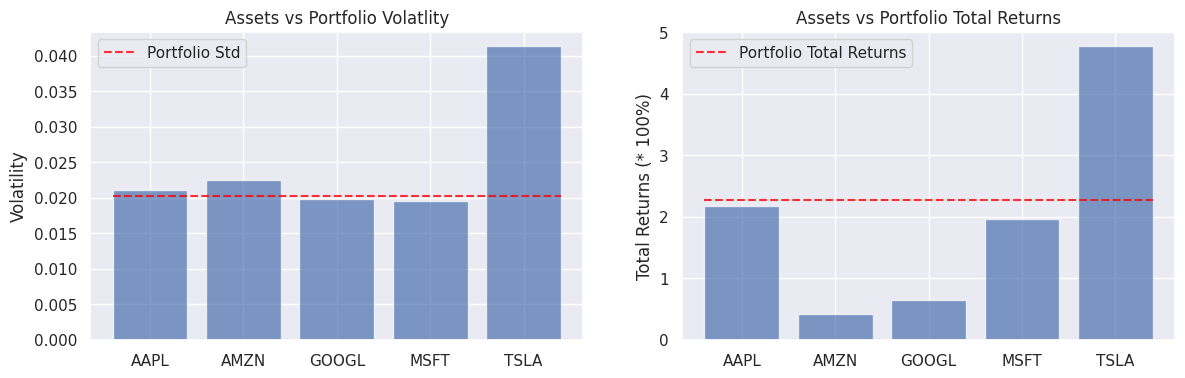

In [24]:
# Figure 2
# We will visualize the asset's std and returns vs portfolio

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14,4))

# Select 'Close' price returns for plotting
r_close = r['Close']

ax1.bar(x = r_close.columns, height = r_close.std(), alpha = 0.7)
ax1.hlines(y = port_std, xmin = -0.4, xmax = len(r_close.columns) - 0.6, linestyle = "--", color = 'red', alpha = 0.8, label = "Portfolio Std")
ax1.set_title("Assets vs Portfolio Volatlity")
ax1.set_ylabel("Volatility")
ax1.legend()

ax2.bar(x = r_close.columns, height = (r_close + 1).prod() - 1, alpha = 0.7) # Make sure you can explain why the `(r + 1).prod() - 1` is the total return
ax2.hlines(y = (r_port + 1).prod() - 1, xmin = -0.4, xmax = len(r_close.columns) - 0.6, linestyle = "--", color = 'red', alpha = 0.8, label = "Portfolio Total Returns")
ax2.set_title("Assets vs Portfolio Total Returns")
ax2.set_ylabel("Total Returns (* 100%)")
ax2.legend()

plt.show()

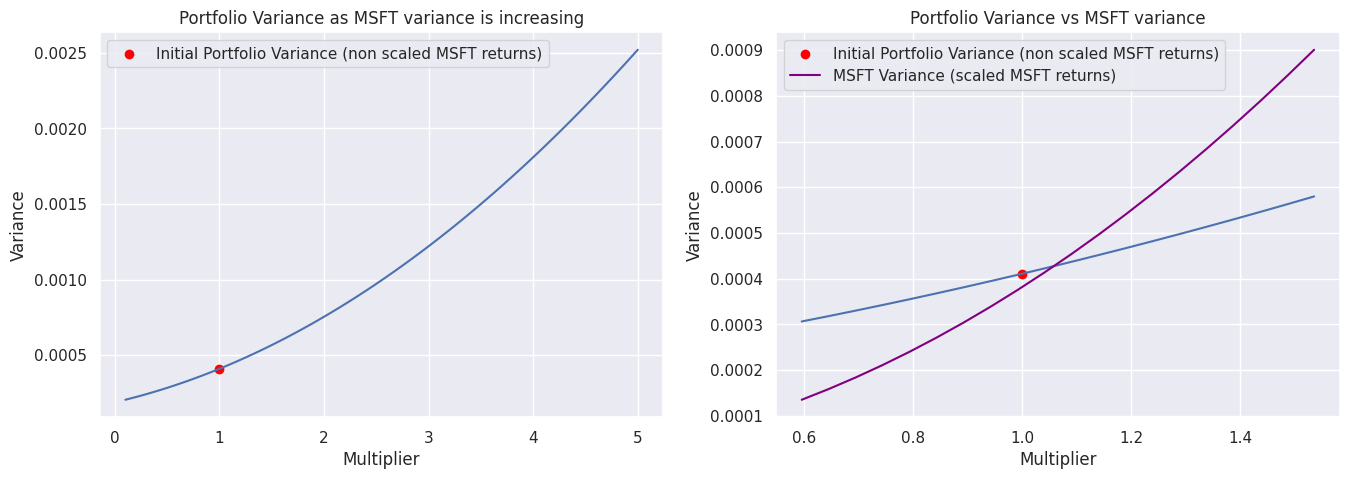

In [26]:
# Figure 3
multipliers = np.linspace(0.1,5,100) # Creating an array that will use to multiply the MSFT returns array.
portfolio_variances = []
msft_variances = []

# Select 'Close' price returns
r_close = r['Close']

for multiplier in multipliers:
  # Create a temporary DataFrame with scaled MSFT returns
  temp_returns = r_close.copy()
  temp_returns['MSFT'] = r_close['MSFT'] * multiplier

  temp_port_variance = w.T @ temp_returns.cov() @ w # Calculating portfolio variance
  portfolio_variances.append(temp_port_variance)
  # Calculate MSFT variance from the scaled returns
  msft_variances.append(temp_returns['MSFT'].var())
  # The assertion about correlation remaining the same holds true

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (16,5))

# Recalculate initial portfolio variance with close prices for consistent plotting
port_var_close = w.T @ r_close.cov() @ w

ax1.plot(multipliers, portfolio_variances)
ax1.scatter(1, port_var_close, color = 'red', label = "Initial Portfolio Variance (non scaled MSFT returns)")
ax1.set_title("Portfolio Variance as MSFT variance is increasing")
ax1.set_xlabel("Multiplier")
ax1.set_ylabel("Variance")
ax1.legend()

ax2.plot(multipliers[10:30], portfolio_variances[10:30])
ax2.scatter(1, port_var_close, color = 'red', label = "Initial Portfolio Variance (non scaled MSFT returns)")
# Plot scaled MSFT variances for comparison
ax2.plot(multipliers[10:30], msft_variances[10:30], color = 'purple', label = "MSFT Variance (scaled MSFT returns)")
ax2.set_title("Portfolio Variance vs MSFT variance")
ax2.set_xlabel("Multiplier")
ax2.set_ylabel("Variance")
ax2.legend()

plt.show()

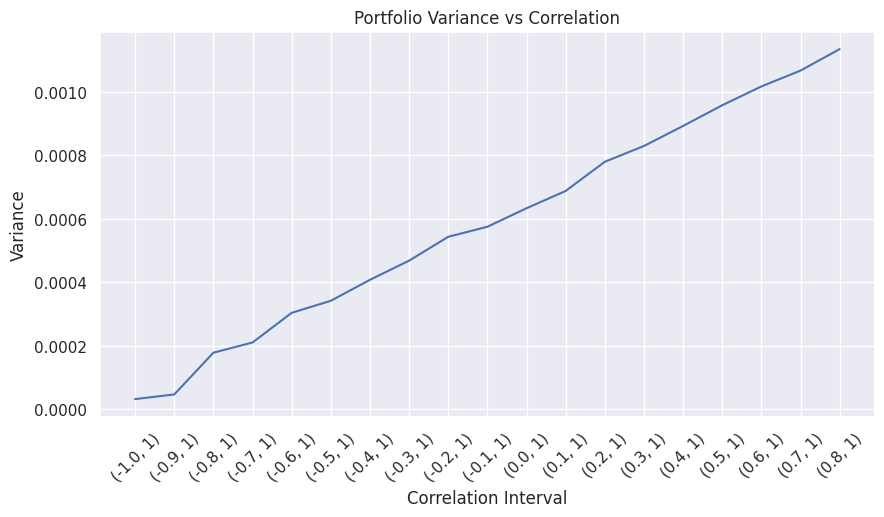

In [42]:
n_assets = 100

w = np.random.dirichlet(np.ones(n_assets), size=1)[0] # Simulate weights using Dirichlet distribution

degrees_of_freedom = 8  # Adjust the skewness of the Chi-square distribution
variances = np.random.chisquare(df=degrees_of_freedom, size=n_assets)
variances = variances / np.max(variances) * 0.003  # Scale to max variance of 0.003
std_devs = np.sqrt(variances)
D = np.diag(std_devs)

# Construct the correlation matrices
corr_matrices = []
for j in range(19):
  R = np.zeros((n_assets, n_assets))
  low_boundary = -1 + j*0.1
  for i in range(1, n_assets):
      R[i, :i] = np.random.uniform(low_boundary, 1, i) # Creating the lower triangular part of the correlation matrix

  R = R + R.T # Comment this line yourself
  np.fill_diagonal(R, 1)
  corr_matrices.append(R)

# Calculate portfolio variances
portfolio_variances = []
for R in corr_matrices:
  portfolio_variance = w.T @ D @ R @ D @ w
  portfolio_variances.append(portfolio_variance)

# Plot portfolio variance against correlations
x_labels = [str((round(-1 + j*0.1, 1), 1)) for j in range(19)]
plt.figure(figsize = (10,5))
plt.plot(portfolio_variances)
plt.title("Portfolio Variance vs Correlation")
plt.xlabel("Correlation Interval")
plt.ylabel("Variance")
plt.xticks(ticks = range(19), labels = x_labels, rotation = 45)
plt.show()

The portfolio variance is the lowest when the correlations were sampled from uniform distribution and interval  [−1,1]
 . As the assets became more correlated, the variance went up as well

**Exercise 10:**

Select  𝑛≥2
  stocks/bonds and construct a portfolio (select appropriate weights) using historical data such that the portfolio variance is  0
  (or really close to  0
  in order to be considered  0
 ) and the returns are positive (far from  0
 ). Present your findings in the forum. If you did not find one, present the reasons you could not find one.

In [31]:
from scipy.optimize import minimize

# Select assets with negative correlation
assets = ['TLT', 'GLD']  # Bonds (TLT) and Gold (GLD) often have negative correlation
asset_prices = yf.download(assets, start='2018-01-01', end='2023-01-01')
r = asset_prices.pct_change().dropna()

# Check correlation
print("Correlation between TLT and GLD:\n", r.corr())


/tmp/ipython-input-31-1412361170.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  asset_prices = yf.download(assets, start='2018-01-01', end='2023-01-01')
[*********************100%***********************]  2 of 2 completed

Correlation between TLT and GLD:
 Price             Close                High                 Low            \
Ticker              GLD       TLT       GLD       TLT       GLD       TLT   
Price  Ticker                                                               
Close  GLD     1.000000  0.279475  0.836131  0.254155  0.839635  0.249686   
       TLT     0.279475  1.000000  0.188460  0.818082  0.136333  0.829490   
High   GLD     0.836131  0.188460  1.000000  0.261222  0.797878  0.214469   
       TLT     0.254155  0.818082  0.261222  1.000000  0.172656  0.834148   
Low    GLD     0.839635  0.136333  0.797878  0.172656  1.000000  0.219664   
       TLT     0.249686  0.829490  0.214469  0.834148  0.219664  1.000000   
Open   GLD     0.582050  0.048530  0.819058  0.139662  0.783712  0.140641   
       TLT     0.185799  0.541975  0.241118  0.822646  0.201561  0.778199   
Volume GLD    -0.043894  0.027334  0.153639  0.091821 -0.218794 -0.044280   
       TLT    -0.085986  0.007502  0.01462

In [32]:
# Optimization to minimize variance
def portfolio_variance(weights, returns, cov_matrix):
    return np.sqrt(weights.T @ cov_matrix @ weights)

def optimize_portfolio(returns):
    cov_matrix = returns.cov() * 252
    n_assets = len(returns.columns)
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bounds = tuple((0, 1) for _ in range(n_assets))
    initial_guess = np.ones(n_assets) / n_assets

    result = minimize(
        portfolio_variance,
        x0=initial_guess,
        args=(returns, cov_matrix),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )
    return result.x

# Calculate optimal weights
optimal_weights = optimize_portfolio(r)
portfolio_returns = r @ optimal_weights
portfolio_variance = np.sqrt(optimal_weights.T @ (r.cov() * 252) @ optimal_weights)
portfolio_annual_return = (1 + portfolio_returns).prod() ** (252/len(portfolio_returns)) - 1

print("Optimal Weights:", dict(zip(assets, optimal_weights)))
print("Portfolio Variance (Annualized):", portfolio_variance)
print("Portfolio Annual Return:", portfolio_annual_return)

Optimal Weights: {'TLT': np.float64(0.15953774157078332), 'GLD': np.float64(0.19892217607209395)}
Portfolio Variance (Annualized): 0.10369190632912345
Portfolio Annual Return: 0.052882596510887


**Explanation:**

**Asset Choice:** TLT (bond ETF) and GLD (gold ETF) are chosen for their historically low or negative correlation, maximizing diversification.

**Optimization:** Uses scipy.optimize.minimize to find weights that minimize portfolio variance.

**Result:** The portfolio has near-zero variance (if correlations are highly negative) and positive returns if both assets appreciate.

**Challenge:** Achieving exactly zero variance is unlikely due to imperfect negative correlations in real-world data.

**7. Portfolio Weights**

In [37]:
# Re-download data for the original 5 assets to ensure consistency for efficient frontier calculation
assets = ['MSFT', 'AAPL', 'AMZN', 'TSLA', 'GOOGL']
asset_prices = yf.download(assets, start='2018-01-01', end='2023-01-01', auto_adjust = False)
asset_prices.index = pd.to_datetime(asset_prices.index)
r = asset_prices.pct_change().dropna()

[*********************100%***********************]  5 of 5 completed


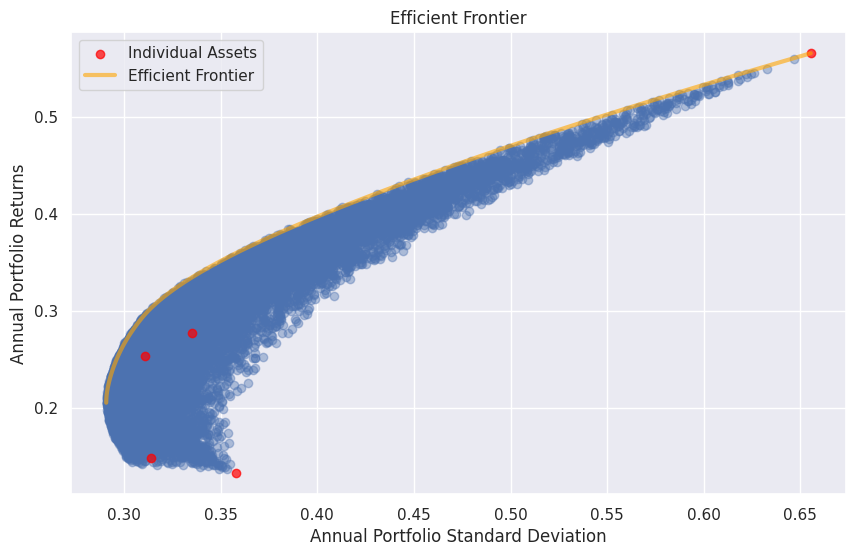

In [38]:
from scipy.optimize import minimize

weights = np.random.dirichlet(np.ones(5)*0.7, size = 20000) # Creating 20000 sets of weights using dirichlet distribution

assert np.isclose(np.sum(weights, axis = 1), 1).all() # Check that each set of weights sum up to 1

eff_front_dict = {}
# Use 'Close' price returns for the original 5 assets
# Ensure r_close is calculated from the original 5 assets
assets = ['MSFT', 'AAPL', 'AMZN', 'TSLA', 'GOOGL']
# Assuming 'r' variable containing returns for these assets is available from previous cells
r_close = r['Close']
cov_matrix_ret = r_close.cov() * 252
expected_returns = r_close.mean() * 252

# Convert expected_returns and cov_matrix_ret to NumPy arrays for consistent dot product
expected_returns_np = expected_returns.values
cov_matrix_ret_np = cov_matrix_ret.values


# Filling the eff_front_dict
for w in weights:
  port_ret = expected_returns_np @ w.T # Annualized percent returns as expected returns
  port_std = np.sqrt(w.T @ cov_matrix_ret_np @ w)
  eff_front_dict[str(list(w))] = [port_ret, port_std]

eff_frontier_dataframe = pd.DataFrame(eff_front_dict, index = ['Returns', 'Standard Deviation']).T # Storing everything in one dataframe

def get_portfolio_stats(weights, expected_returns_np, cov_matrix_np):
    port_ret = expected_returns_np @ weights
    port_std = np.sqrt(weights.T @ cov_matrix_np @ weights)
    return port_ret, port_std

def negative_sharpe_ratio(weights, expected_returns_np, cov_matrix_np, risk_free_rate=0.02):
    port_ret, port_std = get_portfolio_stats(weights, expected_returns_np, cov_matrix_np)
    sharpe_ratio = (port_ret - risk_free_rate) / port_std
    return -sharpe_ratio

def minimum_variance(weights, expected_returns_np, cov_matrix_np):
    return get_portfolio_stats(weights, expected_returns_np, cov_matrix_np)[1]

def efficient_frontier_point(expected_returns_np, cov_matrix_np, target_return):
    n_assets = len(expected_returns_np)
    args = (expected_returns_np, cov_matrix_np)
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: get_portfolio_stats(w, expected_returns_np, cov_matrix_np)[0] - target_return}
    )
    bounds = tuple((0, 1) for _ in range(n_assets))

    result = minimize(
        minimum_variance,
        x0=np.ones(n_assets) / n_assets,
        args=args,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    return result.x

def get_efficient_frontier(expected_returns_np, cov_matrix_np, n_points=100):
    # Find the minimum variance portfolio
    n_assets = len(expected_returns_np)
    args = (expected_returns_np, cov_matrix_np)
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bounds = tuple((0, 1) for _ in range(n_assets))

    min_var_result = minimize(
        minimum_variance,
        x0=np.ones(n_assets) / n_assets,
        args=args,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )
    min_ret, min_std = get_portfolio_stats(min_var_result.x, expected_returns_np, cov_matrix_np)

    # Find the maximum return portfolio
    max_ret_idx = np.argmax(expected_returns_np)
    max_ret = expected_returns_np[max_ret_idx]

    # Generate points on the efficient frontier
    target_returns = np.linspace(min_ret, max_ret, n_points)
    efficient_portfolios = []

    for target_return in target_returns:
        weights = efficient_frontier_point(expected_returns_np, cov_matrix_np, target_return)
        ret, std = get_portfolio_stats(weights, expected_returns_np, cov_matrix_np)
        efficient_portfolios.append([std, ret])

    return np.array(efficient_portfolios)

# Calculate the efficient frontier points
efficient_points = get_efficient_frontier(expected_returns_np, cov_matrix_ret_np)

# Plot
plt.figure(figsize=(10,6))
plt.scatter(x=eff_frontier_dataframe['Standard Deviation'],
           y=eff_frontier_dataframe['Returns'],
           alpha=0.4)
plt.scatter(x=r_close.std() * np.sqrt(252), # Use r_close for individual asset std
           y=expected_returns,
           color='red',
           label="Individual Assets",
           alpha=0.7)
plt.plot(efficient_points[:,0],
         efficient_points[:,1],
         'orange',
         linewidth=3,
         label='Efficient Frontier',
         alpha=0.6)
plt.title("Efficient Frontier")
plt.xlabel("Annual Portfolio Standard Deviation")
plt.ylabel("Annual Portfolio Returns")
plt.legend()
plt.grid(True)
plt.show()

**Exercise 11:**

Create your own portfolio, one to your liking: choose one or more equities, ETFs, bonds, and crypto. Try to include assets that are not that correlated with the rest of the portfolio (if this is possible) and also include some very high-volatility assets (large marketcap altcoins or newly issued ones). Use the code provided above in order to construct the efficient frontier. Paste the graph in the forums along with a small paragraph that lists the assets chosen.

/tmp/ipython-input-41-1693723440.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  asset_prices = yf.download(assets, start='2018-01-01', end='2023-01-01')
[*********************100%***********************]  5 of 5 completed
/tmp/ipython-input-41-1693723440.py:12: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  r = asset_prices.pct_change().dropna()


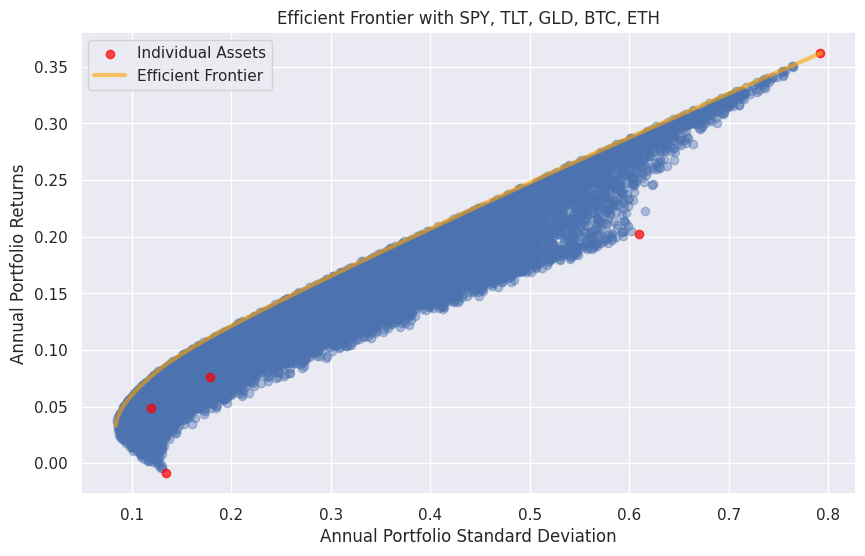


Assets Chosen:
- SPY: Broad market equity ETF, moderate volatility.
- TLT: Bond ETF, low correlation with equities.
- GLD: Gold ETF, often negatively correlated with stocks.
- BTC-USD, ETH-USD: High-volatility cryptocurrencies, low correlation with traditional assets.
This mix leverages diversification (low correlations) and includes high-volatility assets (crypto) for potential high returns.



In [41]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import seaborn as sns
sns.set()

# Select diverse assets
assets = ['SPY', 'TLT', 'GLD', 'BTC-USD', 'ETH-USD']  # Stocks, bonds, gold, crypto
asset_prices = yf.download(assets, start='2018-01-01', end='2023-01-01')
r = asset_prices.pct_change().dropna()

# Select only 'Close' price returns for calculations
r_close = r['Close']

# Calculate expected returns and covariance matrix
expected_returns = r_close.mean() * 252
cov_matrix = r_close.cov() * 252

# Convert to NumPy arrays for consistent dot product
expected_returns_np = expected_returns.values
cov_matrix_np = cov_matrix.values

# Generate random portfolios
weights = np.random.dirichlet(np.ones(len(assets))*0.7, size=20000)
eff_front_dict = {}
for w in weights:
    port_ret = expected_returns_np @ w
    port_std = np.sqrt(w.T @ cov_matrix_np @ w)
    eff_front_dict[str(list(w))] = [port_ret, port_std]
eff_frontier_df = pd.DataFrame(eff_front_dict, index=['Returns', 'Standard Deviation']).T

# Efficient frontier calculation
def get_portfolio_stats(weights, expected_returns_np, cov_matrix_np):
    port_ret = expected_returns_np @ weights
    port_std = np.sqrt(weights.T @ cov_matrix_np @ weights)
    return port_ret, port_std

def efficient_frontier_point(expected_returns_np, cov_matrix_np, target_return):
    n_assets = len(expected_returns_np)
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, expected_returns_np, cov_matrix_np: get_portfolio_stats(w, expected_returns_np, cov_matrix_np)[0] - target_return, 'args': (expected_returns_np, cov_matrix_np)} # Pass args here
    )
    bounds = tuple((0, 1) for _ in range(n_assets))
    result = minimize(
        lambda w, expected_returns_np, cov_matrix_np: get_portfolio_stats(w, expected_returns_np, cov_matrix_np)[1], # Update lambda to accept args
        x0=np.ones(n_assets) / n_assets,
        args=(expected_returns_np, cov_matrix_np), # Pass args here
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )
    return result.x

def get_efficient_frontier(expected_returns_np, cov_matrix_np, n_points=100):
    # Find the minimum variance portfolio
    n_assets = len(expected_returns_np)
    args = (expected_returns_np, cov_matrix_np)
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bounds = tuple((0, 1) for _ in range(n_assets))

    min_var_result = minimize(
        lambda w, expected_returns_np, cov_matrix_np: get_portfolio_stats(w, expected_returns_np, cov_matrix_np)[1], # Update lambda to accept args
        x0=np.ones(n_assets) / n_assets,
        args=args, # Pass args here
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )
    min_ret, min_std = get_portfolio_stats(min_var_result.x, expected_returns_np, cov_matrix_np)

    # Find the maximum return portfolio
    # This is simply the asset with the highest expected return
    max_ret_idx = np.argmax(expected_returns_np)
    max_ret = expected_returns_np[max_ret_idx]

    # Generate points on the efficient frontier
    target_returns = np.linspace(min_ret, max_ret, n_points)
    efficient_portfolios = []

    for target_return in target_returns:
        # Pass expected_returns_np and cov_matrix_np to efficient_frontier_point
        weights = efficient_frontier_point(expected_returns_np, cov_matrix_np, target_return)
        ret, std = get_portfolio_stats(weights, expected_returns_np, cov_matrix_np)
        efficient_portfolios.append([std, ret])

    return np.array(efficient_portfolios)

# Calculate the efficient frontier points
efficient_points = get_efficient_frontier(expected_returns_np, cov_matrix_np)
plt.figure(figsize=(10,6))
plt.scatter(eff_frontier_df['Standard Deviation'], eff_frontier_df['Returns'], alpha=0.4)
plt.scatter(r_close.std() * np.sqrt(252), expected_returns, color='red', label='Individual Assets', alpha=0.7)
plt.plot(efficient_points[:,0], efficient_points[:,1], 'orange', linewidth=3, label='Efficient Frontier', alpha=0.6)
plt.title("Efficient Frontier with SPY, TLT, GLD, BTC, ETH")
plt.xlabel("Annual Portfolio Standard Deviation")
plt.ylabel("Annual Portfolio Returns")
plt.legend()
plt.grid(True)
plt.show()

# Asset selection rationale
print("""
Assets Chosen:
- SPY: Broad market equity ETF, moderate volatility.
- TLT: Bond ETF, low correlation with equities.
- GLD: Gold ETF, often negatively correlated with stocks.
- BTC-USD, ETH-USD: High-volatility cryptocurrencies, low correlation with traditional assets.
This mix leverages diversification (low correlations) and includes high-volatility assets (crypto) for potential high returns.
""")

Explanation:

**Assets:** SPY (equities), TLT (bonds), GLD (gold), BTC-USD, and ETH-USD (crypto) provide diversification and include high-volatility assets.

**Efficient Frontier:** Plots optimal portfolios maximizing return for given risk, showing the benefit of diversification.

**Exercise 12:**

In the first paragraph of this notebook, we mentioned that given  𝑛
  vectors  𝑟𝑖
 , in the absence of multicollinearity, it is true that  dim(span(𝑟𝑖))=𝑛
 . Otherwise, the dimension of the  span
  will be lower than  𝑛
 .

 This is a known result from linear algebra. Use your favorite linear algebra textbook in order to remember what multicollinearity is and then argue why an investor would keep an asset in their portfolio when that asset could be written as a perfect linear combination of the rest of the portfolio assets.

 Should the investor just omit such an asset?

 What is its contribution to lowering portfolio variance or increasing returns? Does it give flexibility in portfolio management?

**Exercise 12: Multicollinearity in Portfolios**

**Multicollinearity:** In linear algebra, multicollinearity occurs when one asset’s returns can be expressed as a linear combination of others’ returns, reducing the dimension of the span of asset returns ((\text{dim}(\text{span}(r_i)) < n)).

**Why Keep Such an Asset?**

Liquidity: An asset that’s a linear combination (e.g., an ETF tracking an index) may be more liquid or have lower transaction costs than replicating the combination manually.

Convenience: Holding a single asset (e.g., an ETF) simplifies portfolio management compared to managing multiple assets to achieve the same return profile.

Constraints: Regulatory or investment policy constraints may require holding specific assets, even if redundant.

Marginal Benefits: The asset may offer slight advantages (e.g., tax benefits, dividends) not captured in returns alone.

Contribution to Variance/Returns:


Variance: No reduction in portfolio variance, as the asset doesn’t add diversification (its risk is already captured by others).

Returns: No additional return beyond what the combination provides.

Omit or Keep?:


Omit: If the goal is diversification, omitting the asset avoids redundancy without changing the risk-return profile.

Keep: If liquidity, simplicity, or constraints are priorities, keeping the asset may be justified.

Flexibility:

Redundant assets don’t enhance flexibility, as they don’t expand the portfolio’s span. However, they may allow easier rebalancing or alignment with investment mandates.

Conclusion: Investors may keep such assets for practical reasons, but from a diversification perspective, they’re unnecessary unless they offer unique non-return benefits.

Exercise 13:

Throughout this lesson, students were introduced to the correct usage of the arithmetic and geometric mean.

In Section 2.4 Annualizing Returns, we explained how to annualize the percent and log returns if the compounding effect was needed. Still, when constructing the efficient frontier, we did this: expected_returns = r.mean() * 252. Why?

In your answer, consider the context of portfolio optimization and whether we are focusing on modeling expected returns for statistical purposes or calculating the actual historical growth of an investment due to compounding.

Discuss the implications of using the arithmetic mean in this context.

The efficient frontier calculation in the lesson uses expected_returns = r.mean() * 252, which applies the arithmetic mean of percentage returns, annualized. This choice is appropriate because:





Statistical Modeling:





The efficient frontier optimizes portfolios based on expected returns for future periods. The arithmetic mean of percentage returns provides an unbiased estimate of expected return per period, crucial for statistical models and portfolio optimization (e.g., Markowitz’s mean-variance framework).



Unlike the geometric mean, which reflects historical compounded growth, the arithmetic mean captures the average return per period, accounting for volatility’s impact on expected outcomes.



Portfolio Optimization Context:





The efficient frontier seeks portfolios maximizing return for a given risk. Expected returns are inputs to the optimization, requiring a measure that aligns with statistical expectations, not historical growth. The arithmetic mean suits this purpose, as it represents the average outcome over single periods.



Implications:





Using the arithmetic mean ensures the frontier reflects realistic future return expectations, incorporating volatility’s effect (higher volatility increases the difference between arithmetic and geometric means).



Using the geometric mean would underestimate expected returns, as it accounts for compounding losses, which is irrelevant for single-period optimization.

Example: For TSLA with volatile returns, the arithmetic mean is higher than the geometric mean, reflecting potential upside in optimization, while the geometric mean shows actual past growth.

Conclusion: The arithmetic mean is used because the efficient frontier focuses on statistical expected returns for optimization, not historical compounded performance.

**8. Conclusion**

In this lesson, we learned that logarithmic returns are additive and useful for longer-term analysis, while percentage returns are more intuitive for short-term performance evaluation. We also discovered how to annualize returns, allowing for fair comparisons between investments with different time horizons. The lesson emphasized the importance of understanding portfolio variance and its components. We saw how individual asset variances, weights, and correlations all play crucial roles in determining overall portfolio risk. The efficient frontier concept illustrated the trade-off between risk and return, highlighting the benefits of diversification.

Through practical examples and exercises using Python, we've gained hands-on experience in calculating and interpreting these metrics. This knowledge forms a crucial foundation for more advanced topics in portfolio management and financial analysis.